In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [4]:
train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
df = train.merge(stores, on="store_nbr", how="left")

df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [6]:
df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,day,month,year
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,1,1,2013
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,1,1,2013
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,1,1,2013
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,1,1,2013
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,1,1,2013


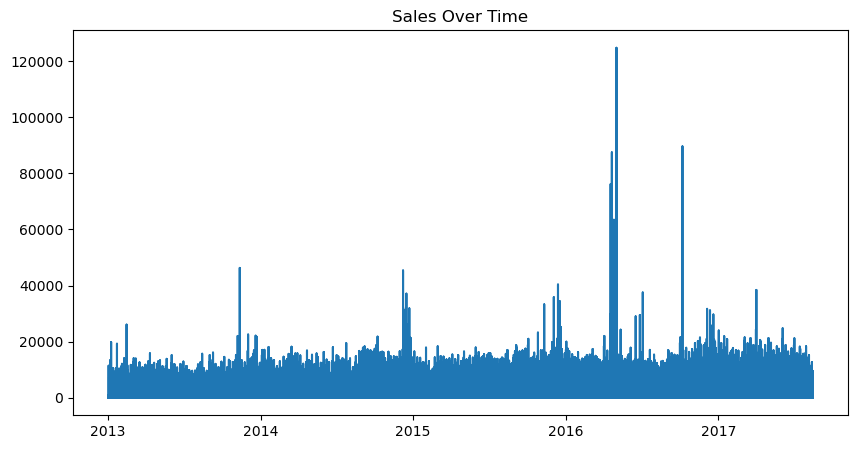

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'])
plt.title("Sales Over Time")
plt.show()

In [10]:
df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)

df['rolling_7'] = df['sales'].rolling(7).mean()

df = df.dropna()

In [11]:
train_data = df[df['date'] < '2017-01-01']
test_data = df[df['date'] >= '2017-01-01']

features = ['day','month','lag_1','lag_7','rolling_7']

X_train = train_data[features]
y_train = train_data['sales']

X_test = test_data[features]
y_test = test_data['sales']

In [12]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
test_data.loc[:, 'prediction'] = preds

In [17]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 711.8476317671025


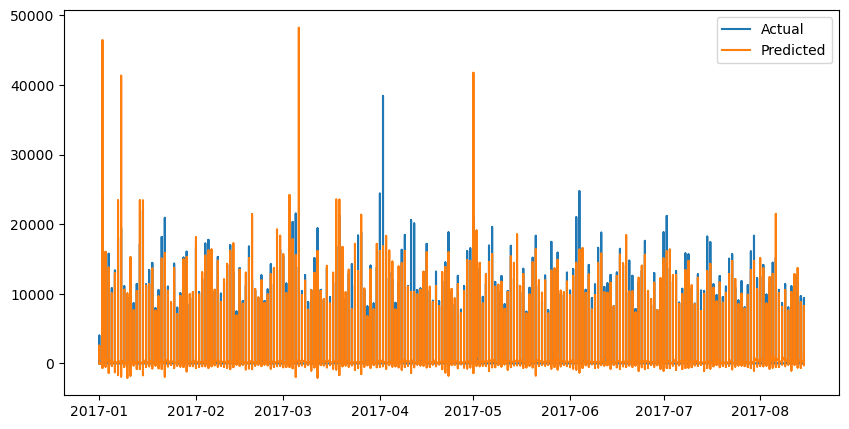

In [18]:
plt.figure(figsize=(10,5))

plt.plot(test_data['date'], test_data['sales'], label='Actual')
plt.plot(test_data['date'], test_data['prediction'], label='Predicted')

plt.legend()
plt.show()

In [19]:
if test_data['prediction'].mean() > train_data['sales'].mean():
    print("📈 Demand is increasing")

if df['day'].mean() > 3:
    print("📅 Weekend sales effect observed")

📈 Demand is increasing
